In [1]:
# Basic import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

#### Importing training data

In [ ]:
df = pd.read_csv("data/StudentsPerformance.csv")

In [5]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


#### Preparing  X and Y variables

In [6]:
X = df.drop(columns="math score")
y = df["math score"]

In [7]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [8]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [9]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

In [10]:
X = preprocessor.fit_transform(X)

In [12]:
X.shape

(1000, 19)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 19), (200, 19), (800,), (200,))

#### Create and Evaluate function to give all metrics after model training

In [14]:
def evaluate_model(true, predicted):

    mae = mean_squared_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)

    return mae, mse, rmse, r2

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "XGB Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=0),
}


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import cross_val_score

N_TRIALS = 50
CV_FOLDS = 5


def make_objective(model_name):
    def objective(trial):
        if model_name == "Ridge Regression":
            params = {"alpha": trial.suggest_float("alpha", 0.01, 100, log=True)}
            model = Ridge(**params)
        elif model_name == "Lasso Regression":
            params = {"alpha": trial.suggest_float("alpha", 0.001, 10, log=True)}
            model = Lasso(**params)
        elif model_name == "KNN Regressor":
            params = {
                "n_neighbors": trial.suggest_int("n_neighbors", 1, 20),
                "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
                "p": trial.suggest_int("p", 1, 2),
            }
            model = KNeighborsRegressor(**params)
        elif model_name == "Decision Tree Regressor":
            params = {
                "max_depth": trial.suggest_int("max_depth", 1, 20),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
                "criterion": trial.suggest_categorical("criterion", ["squared_error", "friedman_mse"]),
            }
            model = DecisionTreeRegressor(**params)
        elif model_name == "Random Forest Regressor":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 50, 300),
                "max_depth": trial.suggest_int("max_depth", 2, 20),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            }
            model = RandomForestRegressor(**params, random_state=42)
        elif model_name == "AdaBoost Regressor":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 50, 300),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 2.0, log=True),
            }
            model = AdaBoostRegressor(**params, random_state=42)
        elif model_name == "XGB Regressor":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 50, 300),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "gamma": trial.suggest_float("gamma", 0, 5),
            }
            model = XGBRegressor(**params, random_state=42, verbosity=0)
        elif model_name == "CatBoost Regressor":
            params = {
                "iterations": trial.suggest_int("iterations", 100, 500),
                "depth": trial.suggest_int("depth", 4, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
            }
            model = CatBoostRegressor(**params, verbose=0, random_state=42)

        scores = cross_val_score(model, X_train, y_train, cv=CV_FOLDS, scoring="r2")
        return scores.mean()

    return objective


print(f"Optuna: {N_TRIALS} trials/model | {CV_FOLDS}-fold CV | maximizing R2\n")

models_to_tune = [k for k in models.keys() if k != "Linear Regression"]

for model_name in models_to_tune:
    study = optuna.create_study(direction="maximize")
    study.optimize(make_objective(model_name), n_trials=N_TRIALS)

    best_params = study.best_params
    best_r2 = study.best_value

    print(f"{model_name}")
    print(f"  Best CV R2 : {best_r2:.4f}")
    print(f"  Best params: {best_params}\n")

    if model_name == "Ridge Regression":
        models[model_name] = Ridge(**best_params)
    elif model_name == "Lasso Regression":
        models[model_name] = Lasso(**best_params)
    elif model_name == "KNN Regressor":
        models[model_name] = KNeighborsRegressor(**best_params)
    elif model_name == "Decision Tree Regressor":
        models[model_name] = DecisionTreeRegressor(**best_params)
    elif model_name == "Random Forest Regressor":
        models[model_name] = RandomForestRegressor(**best_params, random_state=42)
    elif model_name == "AdaBoost Regressor":
        models[model_name] = AdaBoostRegressor(**best_params, random_state=42)
    elif model_name == "XGB Regressor":
        models[model_name] = XGBRegressor(**best_params, random_state=42, verbosity=0)
    elif model_name == "CatBoost Regressor":
        models[model_name] = CatBoostRegressor(**best_params, verbose=0, random_state=42)

print("Optimization complete — models dict updated with best parameters.")

In [ ]:

model_list = []
r2_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(
        y_train, y_pred_train
    )

    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(
        y_test, y_pred_test
    )

    print(list(models.keys()).index(name) + 1, end=". ")
    model_list.append(name)

    print(f"{name} - R2 Score: {model_test_r2:.4f}")
    print(f"Train MAE: {model_train_mae:.4f}")
    print(f"Train MSE: {model_train_mse:.4f}")
    print(f"Train RMSE: {model_train_rmse:.4f}")
    print(f"Train R2: {model_train_r2:.4f}")
    print("-" * 30)
    print(f"Test MAE: {model_test_mae:.4f}")
    print(f"Test MSE: {model_test_mse:.4f}")
    print(f"Test RMSE: {model_test_rmse:.4f}")
    print(f"Test R2: {model_test_r2:.4f}")

    print("Overfitting Check:", model_train_r2 - model_test_r2)
    
    print("=" * 50)

    r2_list.append(model_test_r2)

1. Linear Regression - R2 Score: 0.8797
Train MAE: 28.3788
Train MSE: 28.3788
Train RMSE: 5.3272
Train R2: 0.8741
------------------------------
Test MAE: 29.2763
Test MSE: 29.2763
Test RMSE: 5.4108
Test R2: 0.8797
Overfitting Check: -0.0055666090183881245
2. Ridge Regression - R2 Score: 0.8806
Train MAE: 28.3378
Train MSE: 28.3378
Train RMSE: 5.3233
Train R2: 0.8743
------------------------------
Test MAE: 29.0563
Test MSE: 29.0563
Test RMSE: 5.3904
Test R2: 0.8806
Overfitting Check: -0.00628888698158292
3. Lasso Regression - R2 Score: 0.8253
Train MAE: 43.4784
Train MSE: 43.4784
Train RMSE: 6.5938
Train R2: 0.8071
------------------------------
Test MAE: 42.5064
Test MSE: 42.5064
Test RMSE: 6.5197
Test R2: 0.8253
Overfitting Check: -0.01817353077643946
4. KNN Regressor - R2 Score: 0.7839
Train MAE: 32.6294
Train MSE: 32.6294
Train RMSE: 5.7122
Train R2: 0.8553
------------------------------
Test MAE: 52.5860
Test MSE: 52.5860
Test RMSE: 7.2516
Test R2: 0.7839
Overfitting Check: 0.071

#### Results

In [17]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=["Model", "R2 Score"]).sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
1,Ridge Regression,0.880593
0,Linear Regression,0.879689
5,Random Forest Regressor,0.853788
8,CatBoost Regressor,0.851632
6,AdaBoost Regressor,0.850188
7,XGB Regressor,0.827797
2,Lasso Regression,0.825320
3,KNN Regressor,0.783898
4,Decision Tree Regressor,0.728711


#### Linear Regression

In [18]:
lin_model = LinearRegression(fit_intercept=True)
lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"Linear Regression R2 Score: {score:.4f}")

Linear Regression R2 Score: 0.8797


#### Plot y_pred and y_pred 

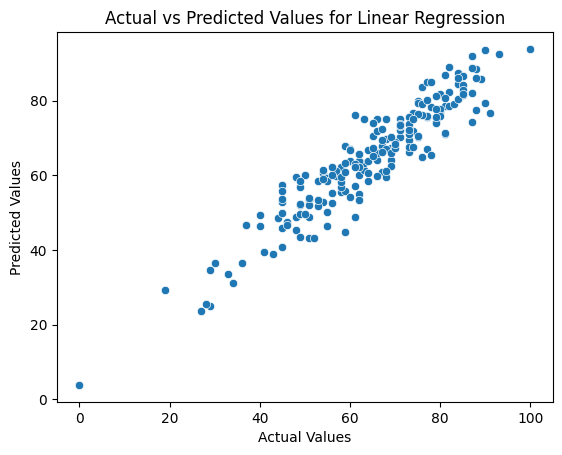

In [20]:
warnings.filterwarnings("ignore")
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values for Linear Regression")
plt.show()

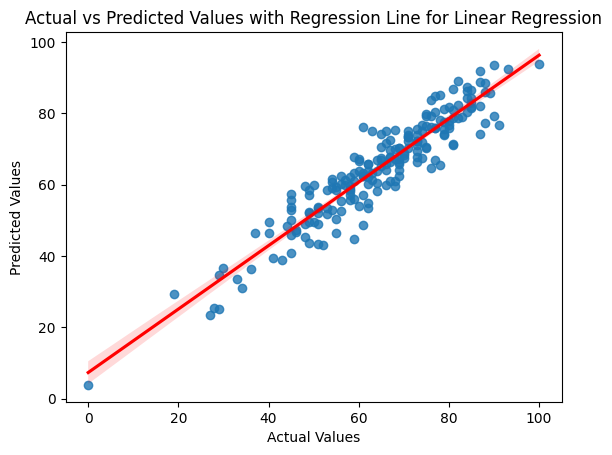

In [23]:
sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values with Regression Line for Linear Regression")
plt.show()